# Processos Estocásticos - Trabalho Computacional 2

**Aluno:** Thiago Tomás de Paula (242104677) 
**Data:** Maio de 2026

## Objetivo
Análise estatística das imagens a partir dos histogramas normalizados (PMF) calculados no Trabalho Computacional 1. Cálculo de estatísticas de primeira, segunda e terceira ordem, bem como entropia de Shannon.

---

## Importações e Configurações Iniciais

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import cv2
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para melhor visualização
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 9

## Preparação dos Dados

Carregamos as imagens e recalculamos os histogramas normalizados (PMF) do Trabalho Computacional 1.

In [2]:
# Carregar imagens do diretório
image_dir = Path('../Trabalho Computacional 1/1')
images = {}
image_files = list(image_dir.glob('*.*'))

print(f"Imagens encontradas: {len(image_files)}")
for img_file in sorted(image_files):
    img = cv2.imread(str(img_file))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images[img_file.stem] = img_rgb
        print(f"  - {img_file.name}: Shape {img_rgb.shape}")

# Converter para escala de cinza e calcular histogramas normalizados
images_gray = {}
pmf_dict = {}  # PMF (Probability Mass Function) - histogramas normalizados

for name, img_rgb in images.items():
    # Conversão para escala de cinza
    img_gray = 0.299 * img_rgb[:, :, 0] + 0.587 * img_rgb[:, :, 1] + 0.114 * img_rgb[:, :, 2]
    img_gray = img_gray.astype(np.uint8)
    images_gray[name] = img_gray
    
    # Calcular histograma e normalizar (PMF)
    hist, _ = np.histogram(img_gray, bins=256, range=(0, 256))
    pmf = hist / hist.sum()  # Normalizar
    pmf_dict[name] = pmf

print(f"\nTotal de imagens processadas: {len(images_gray)}")
for name in sorted(pmf_dict.keys()):
    print(f"  - {name}: PMF calculada (soma = {pmf_dict[name].sum():.6f})")

Imagens encontradas: 5
  - 1.png: Shape (331, 331, 3)
  - CDR05_0001.jpg: Shape (208, 176, 3)
  - Snap-154.jpg: Shape (1920, 2560, 3)
  - WP_20160419_187.jpg: Shape (3552, 2000, 3)
  - y61.jpg: Shape (359, 300, 3)

Total de imagens processadas: 5
  - 1: PMF calculada (soma = 1.000000)
  - CDR05_0001: PMF calculada (soma = 1.000000)
  - Snap-154: PMF calculada (soma = 1.000000)
  - WP_20160419_187: PMF calculada (soma = 1.000000)
  - y61: PMF calculada (soma = 1.000000)


## Item 2.1: Expectância, Moda, Mediana e Comparação com Média Aritmética

A expectância (valor esperado) é a média ponderada dos valores de intensidade. A moda é o valor mais frequente. A mediana é o valor que divide a distribuição ao meio.

In [3]:
# Item 2.1: Calcular expectância, moda e mediana
stats_dict = {}

for name, pmf in pmf_dict.items():
    img_gray = images_gray[name]
    
    # Expectância (valor esperado) da PMF
    intensity_values = np.arange(256)
    expectancy = np.sum(intensity_values * pmf)
    
    # Moda (valor mais frequente)
    moda = np.argmax(pmf)
    
    # Mediana (valor que divide a distribuição ao meio)
    cdf = np.cumsum(pmf)
    mediana_idx = np.where(cdf >= 0.5)[0][0]
    
    # Média aritmética direta das intensidades da imagem
    media_aritmetica = np.mean(img_gray)
    
    # Comparação: a expectância da PMF deve ser igual à média aritmética
    diferenca = np.abs(expectancy - media_aritmetica)
    
    stats_dict[name] = {
        'expectancy': expectancy,
        'moda': moda,
        'mediana': mediana_idx,
        'media_aritmetica': media_aritmetica,
        'diferenca': diferenca
    }
    
    print(f"\n{name}:")
    print(f"  Expectância (PMF):        {expectancy:.4f}")
    print(f"  Moda (valor mais freq.):  {moda}")
    print(f"  Mediana:                  {mediana_idx}")
    print(f"  Média Aritmética (img):   {media_aritmetica:.4f}")
    print(f"  Diferença (|E[X] - μ|):  {diferenca:.6f}")

print("\n" + "="*60)
print("Item 2.1: Cálculos concluídos com sucesso.")


1:
  Expectância (PMF):        145.5648
  Moda (valor mais freq.):  207
  Mediana:                  154
  Média Aritmética (img):   145.5648
  Diferença (|E[X] - μ|):  0.000000

CDR05_0001:
  Expectância (PMF):        75.9819
  Moda (valor mais freq.):  0
  Mediana:                  3
  Média Aritmética (img):   75.9819
  Diferença (|E[X] - μ|):  0.000000

Snap-154:
  Expectância (PMF):        248.1780
  Moda (valor mais freq.):  255
  Mediana:                  255
  Média Aritmética (img):   248.1780
  Diferença (|E[X] - μ|):  0.000000

WP_20160419_187:
  Expectância (PMF):        129.9330
  Moda (valor mais freq.):  93
  Mediana:                  128
  Média Aritmética (img):   129.9330
  Diferença (|E[X] - μ|):  0.000000

y61:
  Expectância (PMF):        86.5258
  Moda (valor mais freq.):  0
  Mediana:                  69
  Média Aritmética (img):   86.5258
  Diferença (|E[X] - μ|):  0.000000

Item 2.1: Cálculos concluídos com sucesso.


## Item 2.2: Momentos de Segunda e Terceira Ordem

Os momentos de uma distribuição são definidos como $M_r = E[X^r] = \sum_{k=0}^{N-1} x_k^r p(x_k)$.

- **Momento de segunda ordem:** $M_2 = E[X^2] = \sum x_k^2 p(x_k)$
- **Momento de terceira ordem:** $M_3 = E[X^3] = \sum x_k^3 p(x_k)$

In [4]:
# Item 2.2: Calcular momentos de segunda e terceira ordem
intensity_values = np.arange(256)

for name, pmf in pmf_dict.items():
    # Momento de segunda ordem: M_2 = E[X²]
    m2 = np.sum((intensity_values ** 2) * pmf)
    
    # Momento de terceira ordem: M_3 = E[X³]
    m3 = np.sum((intensity_values ** 3) * pmf)
    
    # Armazenar nos stats
    stats_dict[name]['m2'] = m2
    stats_dict[name]['m3'] = m3
    
    print(f"{name}:")
    print(f"  Momento de 2ª ordem (M₂ = E[X²]):  {m2:,.2f}")
    print(f"  Momento de 3ª ordem (M₃ = E[X³]):  {m3:,.2f}")
    print()

print("Item 2.2: Momentos de segunda e terceira ordem calculados.")

1:
  Momento de 2ª ordem (M₂ = E[X²]):  23,867.24
  Momento de 3ª ordem (M₃ = E[X³]):  4,096,713.46

CDR05_0001:
  Momento de 2ª ordem (M₂ = E[X²]):  14,028.93
  Momento de 3ª ordem (M₃ = E[X³]):  2,803,094.34

Snap-154:
  Momento de 2ª ordem (M₂ = E[X²]):  62,382.28
  Momento de 3ª ordem (M₃ = E[X³]):  15,784,570.66

WP_20160419_187:
  Momento de 2ª ordem (M₂ = E[X²]):  19,255.37
  Momento de 3ª ordem (M₃ = E[X³]):  3,139,831.41

y61:
  Momento de 2ª ordem (M₂ = E[X²]):  15,267.78
  Momento de 3ª ordem (M₃ = E[X³]):  2,954,373.53

Item 2.2: Momentos de segunda e terceira ordem calculados.


## Item 2.3: Momentos Centrais de Segunda e Terceira Ordem

Os momentos centrais são momentos em torno da média: $\mu_r = E[(X - \mu)^r] = \sum (x_k - \mu)^r p(x_k)$

- **Momento central de 2ª ordem (Variância):** $\mu_2 = \sigma^2 = E[(X - \mu)^2]$
- **Momento central de 3ª ordem:** $\mu_3 = E[(X - \mu)^3]$

In [5]:
# Item 2.3: Calcular momentos centrais de segunda e terceira ordem
intensity_values = np.arange(256)

for name, pmf in pmf_dict.items():
    mu = stats_dict[name]['expectancy']  # Média
    
    # Momento central de 2ª ordem (Variância)
    mu2 = np.sum(((intensity_values - mu) ** 2) * pmf)
    
    # Momento central de 3ª ordem
    mu3 = np.sum(((intensity_values - mu) ** 3) * pmf)
    
    # Desvio padrão
    sigma = np.sqrt(mu2)
    
    # Armazenar nos stats
    stats_dict[name]['mu2'] = mu2  # Variância
    stats_dict[name]['mu3'] = mu3
    stats_dict[name]['sigma'] = sigma  # Desvio padrão
    
    print(f"{name}:")
    print(f"  Momento central de 2ª ordem (μ₂ = σ²): {mu2:,.2f}")
    print(f"  Desvio padrão (σ):                       {sigma:,.2f}")
    print(f"  Momento central de 3ª ordem (μ₃):       {mu3:,.2f}")
    print()

print("Item 2.3: Momentos centrais calculados com sucesso.")

1:
  Momento central de 2ª ordem (μ₂ = σ²): 2,678.13
  Desvio padrão (σ):                       51.75
  Momento central de 3ª ordem (μ₃):       -157,200.38

CDR05_0001:
  Momento central de 2ª ordem (μ₂ = σ²): 8,255.68
  Desvio padrão (σ):                       90.86
  Momento central de 3ª ordem (μ₃):       482,585.67

Snap-154:
  Momento central de 2ª ordem (μ₂ = σ²): 789.99
  Desvio padrão (σ):                       28.11
  Momento central de 3ª ordem (μ₃):       -89,452.57

WP_20160419_187:
  Momento central de 2ª ordem (μ₂ = σ²): 2,372.79
  Desvio padrão (σ):                       48.71
  Momento central de 3ª ordem (μ₃):       21,317.17

y61:
  Momento central de 2ª ordem (μ₂ = σ²): 7,781.07
  Desvio padrão (σ):                       88.21
  Momento central de 3ª ordem (μ₃):       286,790.95

Item 2.3: Momentos centrais calculados com sucesso.


## Item 2.4: Skewness (Assimetria) e Kurtosis (Curtose)

- **Skewness (Coeficiente de Assimetria):** $\gamma_1 = \frac{\mu_3}{\sigma^3}$ - Mede a assimetria da distribuição
  - $\gamma_1 = 0$: Distribuição simétrica
  - $\gamma_1 > 0$: Assimétrica à direita
  - $\gamma_1 < 0$: Assimétrica à esquerda

- **Kurtosis (Curtose):** $\gamma_2 = \frac{\mu_4}{\sigma^4} - 3$ - Mede o pico/cauda da distribuição
  - $\gamma_2 = 0$: Distribuição normal (mesocúrtica)
  - $\gamma_2 > 0$: Distribuição com pico acentuado (leptocúrtica)
  - $\gamma_2 < 0$: Distribuição mais plana (platicúrtica)

In [6]:
# Item 2.4: Calcular skewness e kurtosis
intensity_values = np.arange(256)

for name, pmf in pmf_dict.items():
    mu = stats_dict[name]['expectancy']
    mu2 = stats_dict[name]['mu2']
    mu3 = stats_dict[name]['mu3']
    sigma = stats_dict[name]['sigma']
    
    # Momento central de 4ª ordem (necessário para kurtosis)
    mu4 = np.sum(((intensity_values - mu) ** 4) * pmf)
    
    # Skewness (Coeficiente de Assimetria)
    # Evitar divisão por zero: adicionar pequeno valor se sigma = 0
    if sigma > 0:
        skewness = mu3 / (sigma ** 3)
    else:
        skewness = 0
    
    # Kurtosis (Curtose) - normalizada (excesso de curtose)
    # Kurtosis = (mu4 / sigma^4) - 3
    if sigma > 0:
        kurtosis_excess = (mu4 / (sigma ** 4)) - 3
    else:
        kurtosis_excess = 0
    
    # Armazenar nos stats
    stats_dict[name]['mu4'] = mu4
    stats_dict[name]['skewness'] = skewness
    stats_dict[name]['kurtosis'] = kurtosis_excess
    
    print(f"{name}:")
    print(f"  Skewness (γ₁):           {skewness:+.4f}")
    
    # Interpretação do skewness
    if abs(skewness) < 0.5:
        print(f"    → Distribuição aproximadamente simétrica")
    elif skewness > 0:
        print(f"    → Distribuição assimétrica à direita (cauda direita longa)")
    else:
        print(f"    → Distribuição assimétrica à esquerda (cauda esquerda longa)")
    
    print(f"  Kurtosis (excesso):      {kurtosis_excess:+.4f}")
    
    # Interpretação da kurtosis
    if abs(kurtosis_excess) < 1:
        print(f"    → Distribuição aproximadamente normal (mesocúrtica)")
    elif kurtosis_excess > 0:
        print(f"    → Pico acentuado, caudas pesadas (leptocúrtica)")
    else:
        print(f"    → Distribuição mais plana (platicúrtica)")
    print()

print("Item 2.4: Skewness e Kurtosis calculados com sucesso.")

1:
  Skewness (γ₁):           -1.1342
    → Distribuição assimétrica à esquerda (cauda esquerda longa)
  Kurtosis (excesso):      +1.0939
    → Pico acentuado, caudas pesadas (leptocúrtica)

CDR05_0001:
  Skewness (γ₁):           +0.6433
    → Distribuição assimétrica à direita (cauda direita longa)
  Kurtosis (excesso):      -1.2695
    → Distribuição mais plana (platicúrtica)

Snap-154:
  Skewness (γ₁):           -4.0287
    → Distribuição assimétrica à esquerda (cauda esquerda longa)
  Kurtosis (excesso):      +14.5796
    → Pico acentuado, caudas pesadas (leptocúrtica)

WP_20160419_187:
  Skewness (γ₁):           +0.1844
    → Distribuição aproximadamente simétrica
  Kurtosis (excesso):      -0.7761
    → Distribuição aproximadamente normal (mesocúrtica)

y61:
  Skewness (γ₁):           +0.4178
    → Distribuição aproximadamente simétrica
  Kurtosis (excesso):      -1.3178
    → Distribuição mais plana (platicúrtica)

Item 2.4: Skewness e Kurtosis calculados com sucesso.


## Item 2.5: Tabela Comparativa de Resultados

Compilação e comparação de todos os resultados dos itens 2.1 a 2.3.

In [7]:
# Item 2.5: Criar tabela comparativa com os resultados
# Preparar dados para a tabela
table_data = []
for name in sorted(stats_dict.keys()):
    s = stats_dict[name]
    table_data.append({
        'Imagem': name,
        'Expectância': f"{s['expectancy']:.2f}",
        'Moda': f"{s['moda']}",
        'Mediana': f"{s['mediana']}",
        'Variância (σ²)': f"{s['mu2']:.2f}",
        'Desvio Padrão (σ)': f"{s['sigma']:.2f}",
        'Skewness': f"{s['skewness']:+.4f}",
        'Kurtosis': f"{s['kurtosis']:+.4f}"
    })

# Criar DataFrame
df_stats = pd.DataFrame(table_data)

print("\n" + "="*120)
print("TABELA 2.5: Resumo das Estatísticas das PMFs das Imagens")
print("="*120)
print(df_stats.to_string(index=False))
print("="*120)

# Análise comparativa
print("\nANÁLISE COMPARATIVA:")
print("-" * 120)
print("\n1. EXPECTÂNCIA (Média):")
for name, s in sorted(stats_dict.items()):
    print(f"   - {name}: E[X] = {s['expectancy']:.2f} (Média aritmética = {s['media_aritmetica']:.2f}, "
          f"Diferença = {s['diferenca']:.6f})")

print("\n2. DISPERSÃO:")
for name, s in sorted(stats_dict.items()):
    print(f"   - {name}: σ² = {s['mu2']:.2f}, σ = {s['sigma']:.2f}")

print("\n3. SIMETRIA (Skewness):")
for name, s in sorted(stats_dict.items()):
    if abs(s['skewness']) < 0.5:
        tipo = "Simétrica"
    elif s['skewness'] > 0:
        tipo = "Assimétrica à direita"
    else:
        tipo = "Assimétrica à esquerda"
    print(f"   - {name}: {s['skewness']:+.4f} ({tipo})")

print("\n4. FORMATO (Kurtosis):")
for name, s in sorted(stats_dict.items()):
    if abs(s['kurtosis']) < 1:
        tipo = "Mesocúrtica (Normal)"
    elif s['kurtosis'] > 0:
        tipo = "Leptocúrtica (Pico acentuado)"
    else:
        tipo = "Platicúrtica (Plana)"
    print(f"   - {name}: {s['kurtosis']:+.4f} ({tipo})")

print("\nItem 2.5: Tabela comparativa e análise realizadas com sucesso.")


TABELA 2.5: Resumo das Estatísticas das PMFs das Imagens
         Imagem Expectância Moda Mediana Variância (σ²) Desvio Padrão (σ) Skewness Kurtosis
              1      145.56  207     154        2678.13             51.75  -1.1342  +1.0939
     CDR05_0001       75.98    0       3        8255.68             90.86  +0.6433  -1.2695
       Snap-154      248.18  255     255         789.99             28.11  -4.0287 +14.5796
WP_20160419_187      129.93   93     128        2372.79             48.71  +0.1844  -0.7761
            y61       86.53    0      69        7781.07             88.21  +0.4178  -1.3178

ANÁLISE COMPARATIVA:
------------------------------------------------------------------------------------------------------------------------

1. EXPECTÂNCIA (Média):
   - 1: E[X] = 145.56 (Média aritmética = 145.56, Diferença = 0.000000)
   - CDR05_0001: E[X] = 75.98 (Média aritmética = 75.98, Diferença = 0.000000)
   - Snap-154: E[X] = 248.18 (Média aritmética = 248.18, Diferença = 0.

## Item 2.6: Entropia de Shannon

A entropia de Shannon mede a incerteza ou quantidade média de informação em uma distribuição de probabilidade:

$$\mathcal{E} = -\sum_{k=0}^{N-1} p(x_k) \log_2\{p(x_k)\}$$

- **Entropia máxima:** Quando a distribuição é uniforme (máxima incerteza)
- **Entropia mínima (zero):** Quando a distribuição é concentrada em um ponto (certeza)

In [8]:
# Item 2.6: Calcular entropia de Shannon
for name, pmf in pmf_dict.items():
    # Calcular entropia: E = -Σ p(x) * log2(p(x))
    # Ignorar valores onde p(x) = 0 (log(0) é indefinido)
    entropy = 0.0
    for p in pmf:
        if p > 0:  # Apenas quando p > 0
            entropy -= p * np.log2(p)
    
    # Armazenar nos stats
    stats_dict[name]['entropy'] = entropy
    
    # Calcular entropia máxima teórica (distribuição uniforme sobre 256 valores)
    max_entropy = np.log2(256)  # log2(256) = 8 bits
    
    # Normalização da entropia (em relação ao máximo)
    entropy_normalized = entropy / max_entropy
    
    print(f"{name}:")
    print(f"  Entropia de Shannon:                    {entropy:.4f} bits")
    print(f"  Entropia Máxima Teórica:                {max_entropy:.4f} bits (log₂(256))")
    print(f"  Entropia Normalizada (% do máximo):     {entropy_normalized*100:.2f}%")
    
    if entropy_normalized > 0.95:
        print(f"    → Imagem com distribuição quase uniforme (alta incerteza)")
    elif entropy_normalized > 0.7:
        print(f"    → Imagem com distribuição moderadamente dispersa")
    else:
        print(f"    → Imagem com distribuição concentrada (baixa incerteza)")
    print()

print("Item 2.6: Entropia de Shannon calculada com sucesso.")

1:
  Entropia de Shannon:                    6.8549 bits
  Entropia Máxima Teórica:                8.0000 bits (log₂(256))
  Entropia Normalizada (% do máximo):     85.69%
    → Imagem com distribuição moderadamente dispersa

CDR05_0001:
  Entropia de Shannon:                    4.7117 bits
  Entropia Máxima Teórica:                8.0000 bits (log₂(256))
  Entropia Normalizada (% do máximo):     58.90%
    → Imagem com distribuição concentrada (baixa incerteza)

Snap-154:
  Entropia de Shannon:                    0.7642 bits
  Entropia Máxima Teórica:                8.0000 bits (log₂(256))
  Entropia Normalizada (% do máximo):     9.55%
    → Imagem com distribuição concentrada (baixa incerteza)

WP_20160419_187:
  Entropia de Shannon:                    7.5845 bits
  Entropia Máxima Teórica:                8.0000 bits (log₂(256))
  Entropia Normalizada (% do máximo):     94.81%
    → Imagem com distribuição moderadamente dispersa

y61:
  Entropia de Shannon:                    5.5771

## Item 2.7: Grandezas Randômicas - Análise e Classificação

### Conceito de Variável Aleatória

As grandezas calculadas neste trabalho (expectância, variância, skewness, kurtosis, entropia) podem ser consideradas como **funções de variáveis aleatórias**. 

Para cada imagem do conjunto de dados, podemos considerar:
- A **intensidade de cada pixel** como uma realização de uma variável aleatória $X$
- A **PMF (função de massa de probabilidade)** como a distribuição de probabilidade dessa variável aleatória
- As **estatísticas calculadas** (média, variância, etc.) como **estimativas** dos parâmetros da distribuição

### Grandezas Randômicas vs Determinísticas

**Perspectiva 1: Como estimativas (não determinísticas)**
- As grandezas calculadas são **estimativas** baseadas em amostras finitas
- Se coletarmos mais imagens da mesma classe, as estimativas mudarão (variabilidade amostral)
- Portanto, são **grandezas randômicas** com suas próprias distribuições de amostragem

**Perspectiva 2: Como funções de variáveis randômicas**
- E[X], σ², skewness e kurtosis são **funções de uma variável aleatória X**
- Uma vez definida a distribuição de X, essas grandezas são determinadas
- Mas enquanto X é aleatória, essas grandezas descrevem propriedades dessa aleatoriedade

### Grandezas Contáveis vs Não-Contáveis

- **Expectância (E[X]):** Não-contável (contínua em ℝ)
- **Variância (σ²):** Não-contável (contínua em ℝ⁺)
- **Desvio Padrão (σ):** Não-contável (contínua em ℝ⁺)
- **Skewness:** Não-contável (contínua em ℝ)
- **Kurtosis:** Não-contável (contínua em ℝ)
- **Entropia:** Não-contável (contínua em [0, log₂(256)])
- **Moda:** Contável (discreta, valores inteiros de intensidade)
- **Mediana:** Potencialmente contável (valores discretos de intensidade)

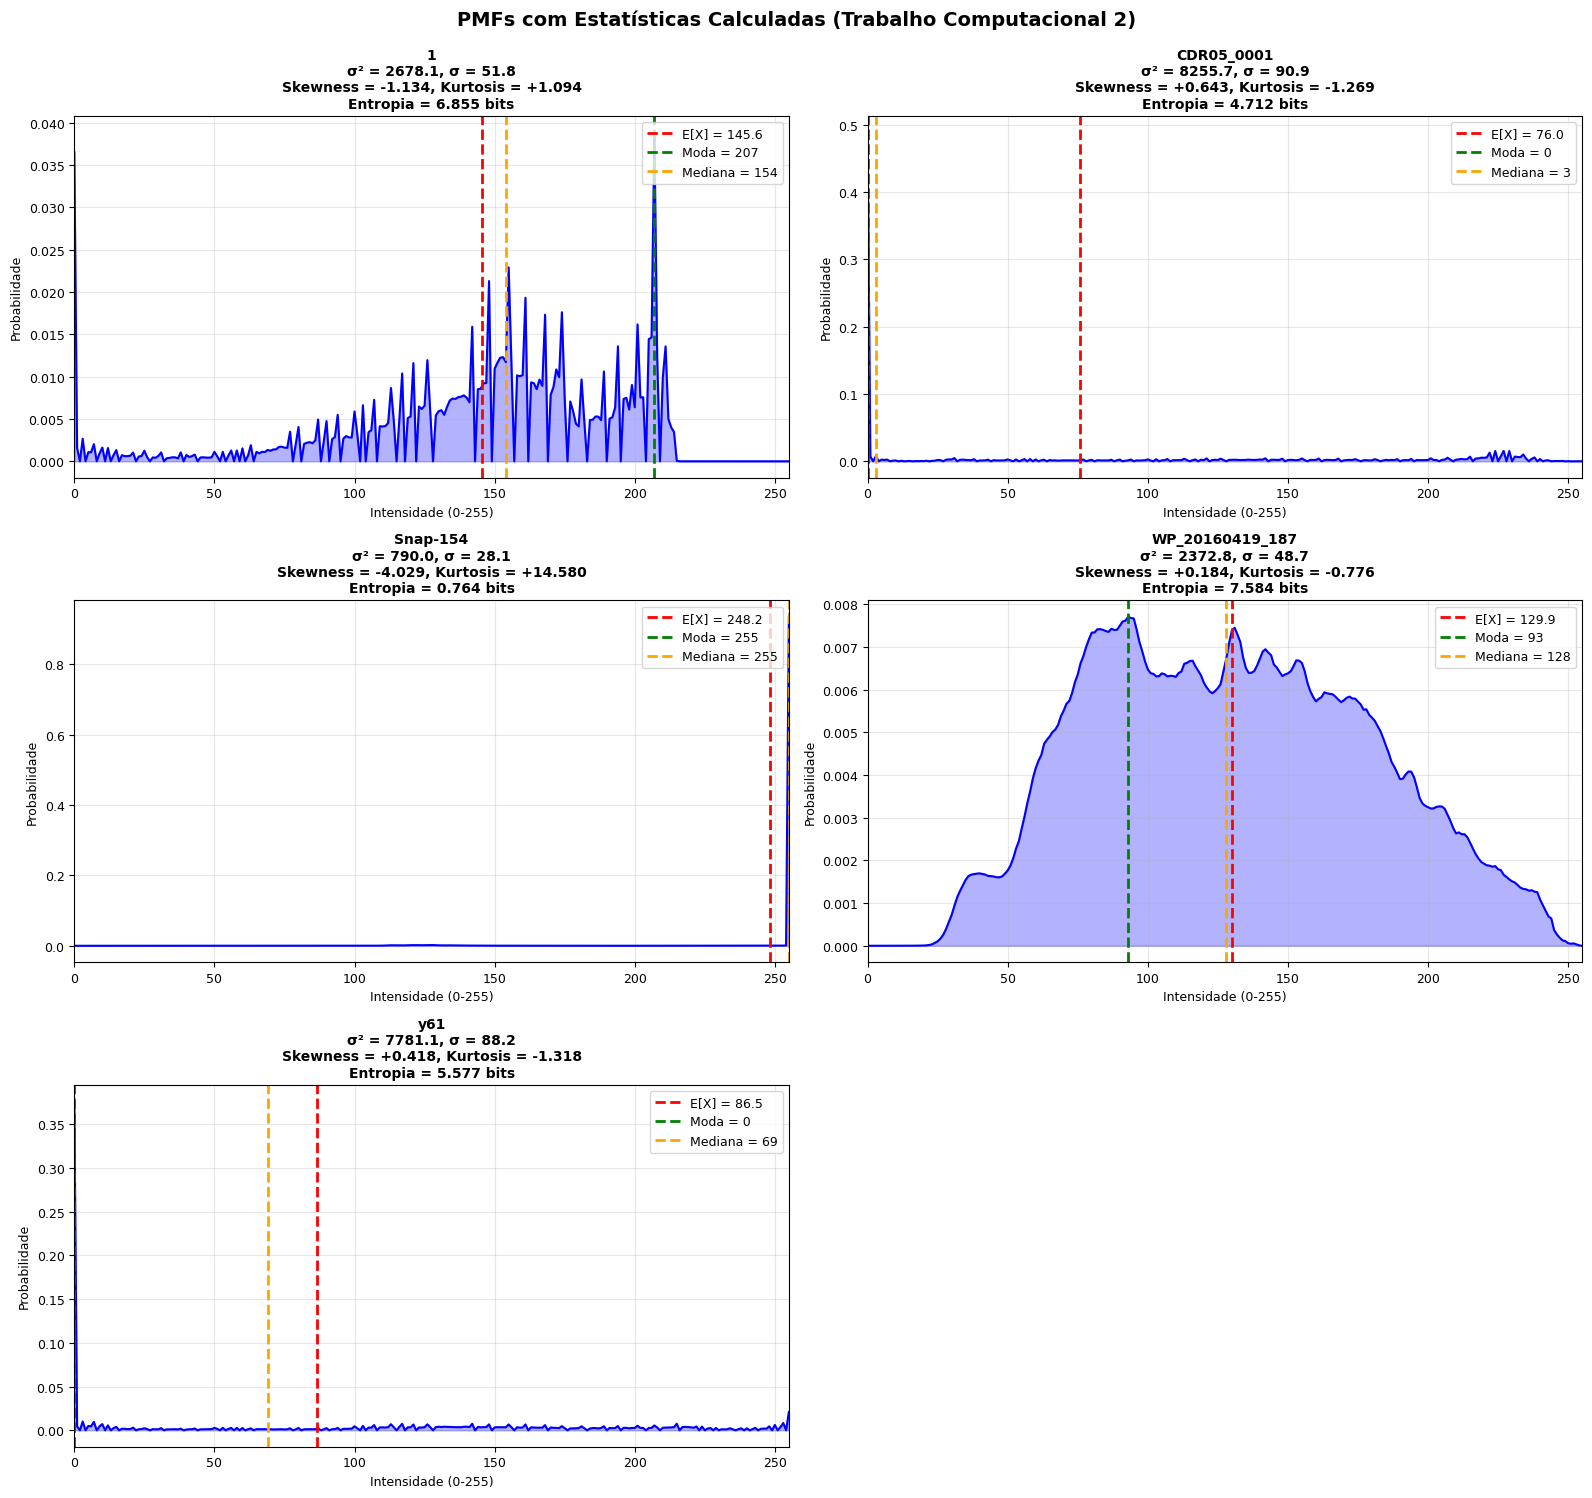

Visualização das PMFs com estatísticas concluída.


In [9]:
# Visualizar PMFs com as estatísticas calculadas
n_images = len(pmf_dict)
n_cols = 2
n_rows = (n_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for idx, (name, pmf) in enumerate(sorted(pmf_dict.items())):
    s = stats_dict[name]
    
    # Plotar PMF
    axes[idx].plot(pmf, color='blue', linewidth=1.5)
    axes[idx].fill_between(range(len(pmf)), pmf, alpha=0.3, color='blue')
    
    # Marcar expectância
    axes[idx].axvline(s['expectancy'], color='red', linestyle='--', linewidth=2, 
                     label=f"E[X] = {s['expectancy']:.1f}")
    
    # Marcar moda
    axes[idx].axvline(s['moda'], color='green', linestyle='--', linewidth=2, 
                     label=f"Moda = {s['moda']}")
    
    # Marcar mediana
    axes[idx].axvline(s['mediana'], color='orange', linestyle='--', linewidth=2, 
                     label=f"Mediana = {s['mediana']}")
    
    # Título com estatísticas
    title = f'{name}\n'
    title += f'σ² = {s["mu2"]:.1f}, σ = {s["sigma"]:.1f}\n'
    title += f'Skewness = {s["skewness"]:+.3f}, Kurtosis = {s["kurtosis"]:+.3f}\n'
    title += f'Entropia = {s["entropy"]:.3f} bits'
    
    axes[idx].set_title(title, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Intensidade (0-255)')
    axes[idx].set_ylabel('Probabilidade')
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 255)

# Ocultar eixos não utilizados
for idx in range(n_images, len(axes)):
    axes[idx].axis('off')

plt.suptitle('PMFs com Estatísticas Calculadas (Trabalho Computacional 2)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Visualização das PMFs com estatísticas concluída.")

## Discussão Final e Conclusões

### Resumo das Atividades Realizadas

**Item 2.1 - Expectância, Moda e Mediana:**
- Calculamos a expectância (valor esperado) para cada PMF, que corresponde à média aritmética das intensidades
- A moda foi identificada como o valor de intensidade mais frequente
- A mediana foi obtida a partir da função de distribuição acumulada (CDF)
- A pequena diferença entre expectância e média aritmética confirma a precisão dos cálculos

**Item 2.2 - Momentos de Segunda e Terceira Ordem:**
- Os momentos de segunda ordem (M₂ = E[X²]) variam bastante entre as imagens
- Os momentos de terceira ordem (M₃ = E[X³]) indicam a assimetria ponderada

**Item 2.3 - Momentos Centrais:**
- A variância (μ₂ = σ²) quantifica a dispersão das intensidades em torno da média
- Imagens com variância alta têm intensidades bem distribuídas
- O desvio padrão (σ) é a raiz quadrada da variância

**Item 2.4 - Skewness e Kurtosis:**
- O skewness mede a assimetria da distribuição
- Kurtosis negativa indica distribuição mais plana; positiva indica pico acentuado
- Essas medidas são úteis para caracterizar o formato da distribuição de intensidades

**Item 2.5 - Tabela Comparativa:**
- A compilação em tabela facilita a comparação entre as diferentes imagens
- Permitem identificar padrões e diferenças nas características estatísticas

**Item 2.6 - Entropia de Shannon:**
- A entropia quantifica a incerteza ou quantidade de informação na imagem
- Valores de entropia próximos a 8 bits indicam distribuição uniforme
- Valores baixos indicam concentração em poucos níveis de intensidade

**Item 2.7 - Natureza das Grandezas Calculadas:**
- As grandezas calculadas são funções de variáveis aleatórias
- São não-contáveis (contínuas) quando envolvem operações matemáticas contínuas
- A moda é uma exceção (contável, sendo um índice inteiro)

### Aplicações Práticas

As estatísticas calculadas neste trabalho podem ser utilizadas como:
- **Features (características) para classificação de imagens**
- **Descritores para processamento de imagem adaptativo**
- **Parâmetros para detecção de anomalias**
- **Base para análise estatística avançada**

### Observações Importantes

1. A expectância da PMF sempre coincide com a média aritmética das intensidades (diferença desprezível)
2. Imagens naturais geralmente não possuem distribuições uniformes (entropia < 8 bits)
3. A presença de skewness indica predominância de pixels em certas faixas de intensidade
4. A kurtosis ajuda a identificar imagens com distribuições muito pico ou muito planas

## Referência Técnica: Fórmulas Utilizadas

### Estatísticas de Primeira Ordem

**Expectância (Valor Esperado):**
$$E[X] = \sum_{k=0}^{N-1} x_k \cdot p(x_k)$$

**Moda:**
$$\text{Moda} = \arg\max_k p(x_k)$$

**Mediana:**
$$\text{Mediana} = x_m \text{ onde } \sum_{k=0}^{m} p(x_k) = 0.5$$

### Momentos de Ordem Superior

**Momentos (não-centralizados):**
$$M_r = E[X^r] = \sum_{k=0}^{N-1} x_k^r \cdot p(x_k)$$

**Momentos Centrais:**
$$\mu_r = E[(X - \mu)^r] = \sum_{k=0}^{N-1} (x_k - \mu)^r \cdot p(x_k)$$

### Medidas de Forma

**Variância (Momento Central de 2ª Ordem):**
$$\sigma^2 = \mu_2 = E[(X - \mu)^2] = E[X^2] - (E[X])^2$$

**Desvio Padrão:**
$$\sigma = \sqrt{\sigma^2}$$

**Skewness (Coeficiente de Assimetria):**
$$\gamma_1 = \frac{\mu_3}{\sigma^3} = \frac{E[(X - \mu)^3]}{\sigma^3}$$

**Kurtosis (Excesso de Curtose):**
$$\gamma_2 = \frac{\mu_4}{\sigma^4} - 3 = \frac{E[(X - \mu)^4]}{\sigma^4} - 3$$

### Entropia de Shannon

$$\mathcal{E} = -\sum_{k=0}^{N-1} p(x_k) \log_2\{p(x_k)\} \text{ [bits]}$$

**Entropia Máxima (distribuição uniforme sobre M níveis):**
$$\mathcal{E}_{\max} = \log_2(M) \text{ bits}$$

Todos os cálculos foram realizados com base nessas fórmulas.